# Deep Learning Architectures for Pneumonia Detection: Multi-Scale Analysis with Explainable AI

**ResNet50 Fine-Tuned Models Notebook**

**Description:** This notebook fine-tunes the best performing ResNet50 model on higher resolution images (64x64) to improve performance for subsequent XAI analysis.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import os
import sys
import time
from datetime import datetime
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # 0=all, 1=info, 2=warning, 3=error
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN optimizations for reproducibility

# Disable verbose output from TensorFlow during training
tf_verbosity = 1  # 0 = silent, 1 = progress bar, 2 = one line per epoch

# Import custom utilities
from utils.data_utils import load_and_preprocess_multiscale_data
from utils.finetune_utils import (
    load_pretrained_model, extract_model_params,
    freeze_layers, generate_tuned_model_path
)
from utils.model.resnet_utils import adapt_resnet50_for_resolution, transfer_resnet50_weights
from utils.train_utils import get_callbacks
from utils.eval_utils import evaluate_model
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix
from utils.logger_utils import ModelLogger

2025-06-20 09:06:26.465755: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-20 09:06:26.610805: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750406786.674822   51453 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750406786.694488   51453 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-20 09:06:26.829128: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Core Variables

In [2]:
# Global seed for reproducibility
RANDOM_SEED = 42

# Architecture and paths
ARCHITECTURE = 'resnet_50'                # Architecture name
DATA_PATH = '../data/'                    # Path to the dataset
OUTPUT_PATH = '../output/'                # Path to save output files
MODEL_PATH = OUTPUT_PATH + 'models/'      # Path to save models
LOG_PATH = OUTPUT_PATH + 'logs/'          # Path to save logs

# Fine-tuning parameters
ORIGINAL_SIZE = 28                        # Original training image size
TARGET_SIZE = 64                          # Target fine-tuning image size
FINE_TUNE_LR = 0.0001                     # Lower learning rate for fine-tuning (10x reduction)
FINE_TUNE_EPOCHS = 30                     # Number of fine-tuning epochs

# Architecture-specific freeze ratios
# - Higher ratio = more frozen layers = preserves more pre-trained features
# - Lower ratio = fewer frozen layers = allows more adaptation to new resolution
FREEZE_RATIOS = {
    'alexnet': 0.85,      # AlexNet: 85% - with 29 layers, this gives ~25 frozen, 4 trainable
    'resnet_18': 0.60,    # ResNet18: 60% - lower due to residual connections
    'resnet_50': 0.80,    # ResNet50: 80% - higher due to depth (50 layers)
    'densenet_169': 0.75  # DenseNet169: 75% - dense connections benefit from more frozen early layers
}

FREEZE_RATIO = FREEZE_RATIOS[ARCHITECTURE]
print(f"Using freeze ratio for {ARCHITECTURE}: {FREEZE_RATIO*100:.0f}%")

# Model selection parameters
CHOSEN_METRIC = 'val_AUC'       # Metric to be used for model selection
MODE = 'max'                    # Whether to maximize or minimize the chosen metric

# Ensure directories exist
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(LOG_PATH, exist_ok=True)

Using freeze ratio for resnet_50: 80%


# Load Best Pre-trained Model

In [3]:
# Load the specified pre-trained model
MODEL_FILENAME = 'resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras'
best_model_path = os.path.join(MODEL_PATH, MODEL_FILENAME)

print(f"Loading pre-trained model: {best_model_path}")
pretrained_model = load_pretrained_model(best_model_path)
print(f"✓ Loaded model with {pretrained_model.count_params():,} parameters")

# Extract parameters from the model filename
original_params = extract_model_params(MODEL_FILENAME)
print("Parameters extracted from model filename:")
for key, value in original_params.items():
    print(f"  {key}: {value}")

Loading pre-trained model: ../output/models/resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras
Loading model from: ../output/models/resnet_50_augmented_b32_lr0.001_dr0.3_pneumonia_model.keras


I0000 00:00:1750406791.409669   51453 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model loaded successfully: functional_7
✓ Loaded model with 23,582,978 parameters
Parameters extracted from model filename:
  batch_size: 32
  learning_rate: 0.001
  dropout_rate: 0.3
  augmented: True
  dropout_mode: fixed


# Data Loading & Preprocessing

In [4]:
# Load data with target resolution
print(f"Loading data with {TARGET_SIZE}x{TARGET_SIZE} resolution...")
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_multiscale_data(
    DATA_PATH,
    image_size=TARGET_SIZE,
    augment=original_params['augmented'],  # Use same augmentation as original model
    batch_size=original_params['batch_size'],
    seed=RANDOM_SEED
)
print(f"✓ Data loaded successfully")

Loading data with 64x64 resolution...

Dataset shapes - 64x64 resolution:
Train - images: (4708, 64, 64)  labels: (4708, 1)
Val   - images: (524, 64, 64)  labels: (524, 1)
Test  - images: (624, 64, 64)  labels: (624, 1)
✓ Data loaded successfully
✓ Data loaded successfully


# Model Adaptation & Fine-tuning Setup

In [5]:
# Adapt the ResNet50 model for the new resolution
print(f"\nAdapting ResNet50 from {ORIGINAL_SIZE}x{ORIGINAL_SIZE} to {TARGET_SIZE}x{TARGET_SIZE}...")

adapted_model = adapt_resnet50_for_resolution(
    pretrained_model, 
    TARGET_SIZE, 
    dropout_rate=original_params['dropout_rate']
)

print(f"✓ ResNet50 successfully adapted from {ORIGINAL_SIZE}x{ORIGINAL_SIZE} to {TARGET_SIZE}x{TARGET_SIZE}")

# Transfer weights from the original model to the adapted model
print("Transferring compatible weights...")
adapted_model = transfer_resnet50_weights(pretrained_model, adapted_model)

# Freeze layers for fine-tuning
print(f"\nApplying freeze ratio of {FREEZE_RATIO*100:.0f}%...")
adapted_model = freeze_layers(adapted_model, freeze_ratio=FREEZE_RATIO)

print(f"\nModel setup complete for fine-tuning:")
print(f"  Architecture: ResNet50")
print(f"  Original resolution: {ORIGINAL_SIZE}x{ORIGINAL_SIZE}")
print(f"  Target resolution: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"  Freeze ratio: {FREEZE_RATIO*100:.0f}%")

adapted_model.summary()


Adapting ResNet50 from 28x28 to 64x64...
Building new ResNet50 for 64x64 resolution...
Using dropout rate: 0.3
✓ ResNet50 successfully adapted from (None, 28, 28, 1) to (64, 64, 1)
Original parameters: 23,582,978
Adapted parameters: 23,582,978
✓ ResNet50 successfully adapted from 28x28 to 64x64
Transferring compatible weights...

Transferring ResNet50 weights...
✓ Conv2D layer conv1: 64 filters
✓ BatchNorm layer bn1
✓ Conv2D layer stage1_block1_conv1: 64 filters
✓ BatchNorm layer stage1_block1_bn1
✓ Conv2D layer stage1_block1_conv2: 64 filters
✓ BatchNorm layer stage1_block1_bn2
✓ Conv2D layer stage1_block1_conv3: 256 filters
✓ Conv2D layer stage1_block1_shortcut_conv: 256 filters
✓ BatchNorm layer stage1_block1_bn3
✓ BatchNorm layer stage1_block1_shortcut_bn
✓ Conv2D layer stage1_block2_conv1: 64 filters
✓ BatchNorm layer stage1_block2_bn1
✓ Conv2D layer stage1_block2_conv2: 64 filters
✓ BatchNorm layer stage1_block2_bn2
✓ Conv2D layer stage1_block2_conv3: 256 filters
✓ BatchNorm lay

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 64, 64,    │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 64, 64,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 64, 64,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 32, 32,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │      4,160 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv3 │ (None, 32, 32,    │     16,640 │ stage1_block1_re… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 32, 32,    │     16,640 │ maxpool1[0][0]    │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn3   │ (None, 32, 32,    │      1,024 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 32, 32,    │      1,024 │ stage1_block1_sh… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 256)              │            │ stage1_block1_sh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu3 │ (None, 32, 32,    │          0 │ stage1_block1_ad

 Total params: 23,582,978 (89.96 MB)

 Trainable params: 14,980,098 (57.14 MB)

 Non-trainable params: 8,602,880 (32.82 MB)

# Model Compilation

In [6]:
# Compile for fine-tuning with lower learning rate
adapted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',  # Updated to match one-hot encoded labels
    metrics=['accuracy', 'AUC']
)

print(f"\nModel compiled for fine-tuning:")
print(f"  Optimizer: Adam (lr={FINE_TUNE_LR})")
print(f"  Loss: Categorical crossentropy")
print(f"  Metrics: Accuracy, AUC")


Model compiled for fine-tuning:
  Optimizer: Adam (lr=0.0001)
  Loss: Categorical crossentropy
  Metrics: Accuracy, AUC


# Fine-Tuning Setup

In [7]:
# Generate path for fine-tuned model
tuned_model_path = generate_tuned_model_path(
    original_params, 
    TARGET_SIZE, 
    MODEL_PATH, 
    ARCHITECTURE
)
print(f"Fine-tuned model will be saved to: {tuned_model_path}")

# Setup logger for fine-tuning
logger = ModelLogger()
tuned_model_info = {
    "model_name": f"{ARCHITECTURE}_tuned",
    "original_model": best_model_path,
    "original_size": ORIGINAL_SIZE,
    "target_size": TARGET_SIZE,
    "fine_tune_lr": FINE_TUNE_LR,
    "freeze_ratio": FREEZE_RATIO,
    "epochs": FINE_TUNE_EPOCHS,
    "batch_size": original_params['batch_size'],
    "augmented": original_params['augmented'],
    "dropout_rate": original_params['dropout_rate'],
    "random_seed": RANDOM_SEED
}
logger.initialize_run(tuned_model_info)

Fine-tuned model will be saved to: ../output/models/resnet_50_tuned_augmented_b32_lr0.001_dr0.3_64px_pneumonia_model.keras


# Fine-tuning Training


Starting fine-tuning for 30 epochs...
Epoch 1/30


I0000 00:00:1750406804.683667   52007 service.cc:148] XLA service 0x70b9cc014f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750406804.683934   52007 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-06-20 09:06:44.982472: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750406807.037905   52007 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-20 09:06:47.816656: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cud

  1/148 ━━━━━━━━━━━━━━━━━━━━ 48:01 20s/step - AUC: 0.9062 - accuracy: 0.7812 - loss: 0.8638

I0000 00:00:1750406816.386277   52007 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - AUC: 0.8751 - accuracy: 0.7950 - loss: 0.5789

2025-06-20 09:07:15.083186: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,32,32]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-06-20 09:07:15.509282: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,128,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,128,16,16]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - AUC: 0.8753 - accuracy: 0.7952 - loss: 0.5778

2025-06-20 09:07:24.157037: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-06-20 09:07:24.205872: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[12,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,64,32,32]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF

148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 215ms/step - AUC: 0.8755 - accuracy: 0.7955 - loss: 0.5768 - val_AUC: 0.9170 - val_accuracy: 0.7939 - val_loss: 0.3601 - learning_rate: 1.0000e-04
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - AUC: 0.9757 - accuracy: 0.9195 - loss: 0.1979 - val_AUC: 0.9783 - val_accuracy: 0.9294 - val_loss: 0.2043 - learning_rate: 1.0000e-04
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - AUC: 0.9819 - accuracy: 0.9346 - loss: 0.1744 - val_AUC: 0.9680 - val_accuracy: 0.8950 - val_loss: 0.2281 - learning_rate: 1.0000e-04
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - AUC: 0.9828 - accuracy: 0.9333 - loss: 0.1670 - val_AUC: 0.9747 - val_accuracy: 0.9103 - val_loss: 0.2059 - learning_rate: 1.0000e-04
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - AUC: 0.9860 - accuracy: 0.9427 - loss: 0.1492 - val_AUC: 0.9460 - val_accuracy: 0.8492 - val_loss: 0.3058 - learning_rate: 1.0000e-04
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step -

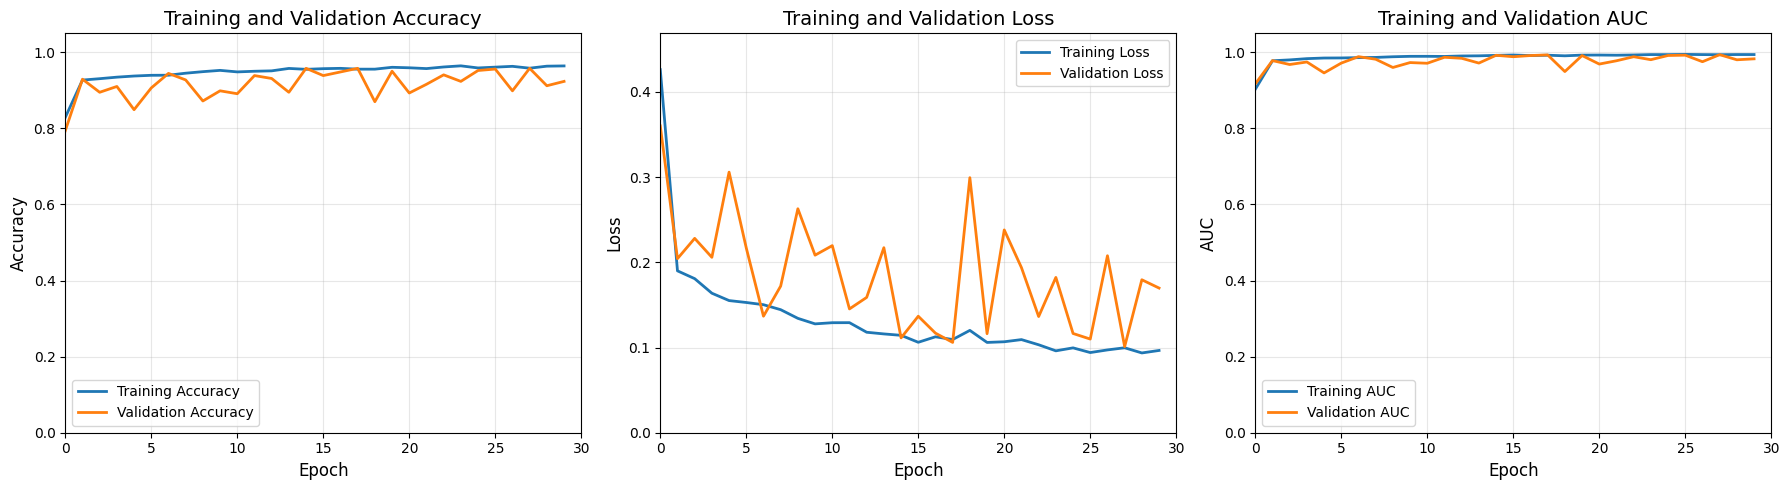

In [8]:
# Get callbacks for fine-tuning
callbacks = get_callbacks(
    tuned_model_path,
    monitor='val_AUC',
    mode='max',
    patience=10,
    factor=0.5  # Use lower factor for fine-tuning (more aggressive LR reduction)
)

# Start fine-tuning
print(f"\nStarting fine-tuning for {FINE_TUNE_EPOCHS} epochs...")
start_time = time.time()

history = adapted_model.fit(
    train_dataset,
    validation_data=(val_images, val_labels),
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=tf_verbosity
)

exec_time = round(time.time() - start_time, 2)
print(f"\nFine-tuning completed in {exec_time} seconds")

# Save training info to logger
logger.add_training_info(history, exec_time)

# Set final model for evaluation
final_model = adapted_model

print("✓ Fine-tuning completed successfully!")

# Plot training history
plot_training_history(history)

# Evaluation


Evaluating fine-tuned model on test set...
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - AUC: 0.9527 - accuracy: 0.9021 - loss: 0.3087

2025-06-20 09:15:56.895609: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-06-20 09:15:56.958599: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,32,32]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 280ms/step - AUC: 0.9525 - accuracy: 0.9013 - loss: 0.3097
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step


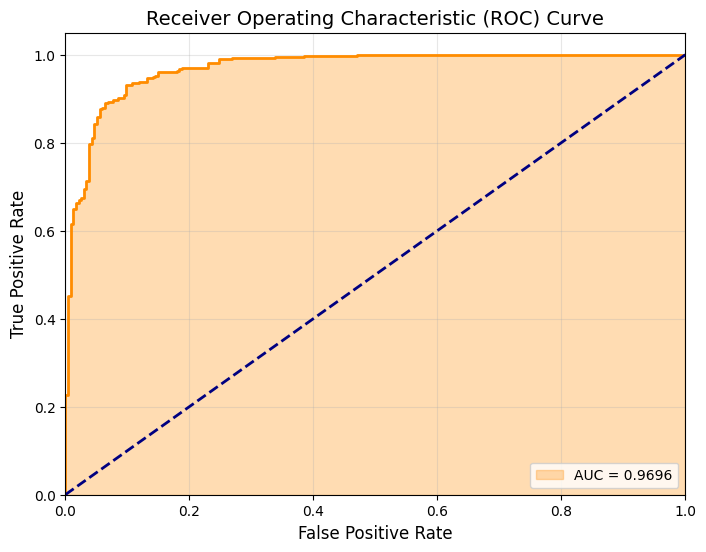

ROC AUC Score: 0.969581


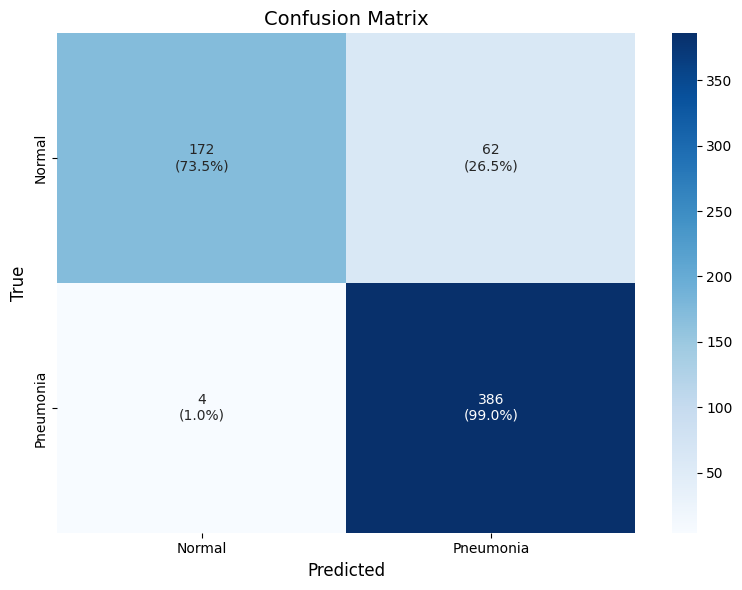


Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.74      0.84       234
   Pneumonia       0.86      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.92      0.86      0.88       624
weighted avg       0.90      0.89      0.89       624



In [9]:
# Evaluate the fine-tuned model (using model from memory)
print("\nEvaluating fine-tuned model on test set...")

# Evaluate using the final model
results = evaluate_model(final_model, test_images, test_labels, verbose=tf_verbosity)

# Add evaluation results to logger
logger.add_evaluation_results(results)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print("\nClassification Report:")
print(results['classification_report'])

# Save Results

In [10]:
# Save fine-tuning log
tuned_log_path = os.path.join(LOG_PATH, f"{ARCHITECTURE}_tuned_{TARGET_SIZE}px_info.json")
logger.save(tuned_log_path)

print(f"\n✅ Fine-tuning completed successfully!")
print(f"📁 Model saved: {tuned_model_path}")
print(f"📊 Logs saved: {tuned_log_path}")
print(f"🎯 Final accuracy: {results['test_accuracy']:.4f}")
print(f"📈 Final AUC: {results['test_auc']:.4f}")
print(f"🔍 The ResNet50 model is now ready for XAI analysis at {TARGET_SIZE}x{TARGET_SIZE} resolution.")

Run information saved to ../output/logs/resnet_50_tuned_64px_info.json

✅ Fine-tuning completed successfully!
📁 Model saved: ../output/models/resnet_50_tuned_augmented_b32_lr0.001_dr0.3_64px_pneumonia_model.keras
📊 Logs saved: ../output/logs/resnet_50_tuned_64px_info.json
🎯 Final accuracy: 0.8942
📈 Final AUC: 0.9499
🔍 The ResNet50 model is now ready for XAI analysis at 64x64 resolution.
